<a href="https://colab.research.google.com/github/walmirpacheco/Calculo_de_Metricas_de_Avaliacao_de_Aprendizado/blob/main/C%C3%A1lculo_de_M%C3%A9tricas_de_Avalia%C3%A7%C3%A3o_de_Aprendizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
# PASSO 1: DADOS DE EXEMPLO
print("\n" + "="*50)
print("PASSO 1: Criando dados de exemplo")
print("="*50)

# Dados sintéticos para classificação binária
X, y = make_classification(n_samples=1000,
                          n_features=20,
                          n_informative=15,
                          n_redundant=5,
                          n_classes=2,
                          random_state=42)

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar um classificador
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Fazer previsões
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Probabilidades para ROC

print(f"Dados criados: {len(X)} amostras")
print(f"Divisão: Treino={len(X_train)}, Teste={len(X_test)}")



PASSO 1: Criando dados de exemplo
Dados criados: 1000 amostras
Divisão: Treino=700, Teste=300



PASSO 2: Gerando Matriz de Confusão
Matriz de Confusão:
[[142  18]
 [ 16 124]]


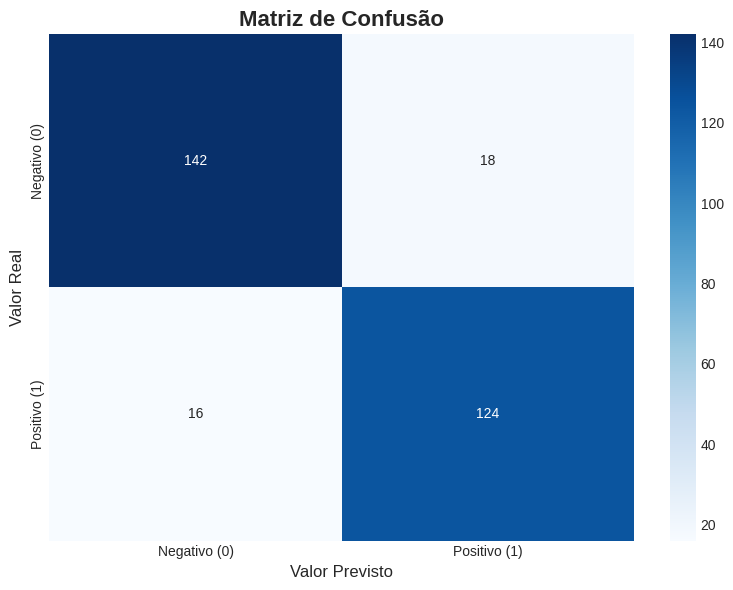

In [4]:
# PASSO 2: GERAR MATRIZ DE CONFUSÃO
print("\n" + "="*50)
print("PASSO 2: Gerando Matriz de Confusão")
print("="*50)

# Calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(cm)

# Visualizar matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'])
plt.title('Matriz de Confusão', fontsize=16, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Previsto', fontsize=12)
plt.tight_layout()
plt.show()


In [5]:
# PASSO 3: LER MATRIZ DE CONFUSÃO LINHA POR COLUNA
# E CALCULAR VP, VN, FP, FN
print("\n" + "="*50)
print("PASSO 3: Lendo Matriz de Confusão linha por coluna")
print("="*50)

# Extrair valores da matriz de confusão
VP = cm[1, 1]  # Verdadeiros Positivos
VN = cm[0, 0]  # Verdadeiros Negativos
FP = cm[0, 1]  # Falsos Positivos
FN = cm[1, 0]  # Falsos Negativos

print("Leitura da Matriz de Confusão linha por coluna:")
print(f"Linha 0, Coluna 0 (VN): {VN} - Verdadeiros Negativos")
print(f"Linha 0, Coluna 1 (FP): {FP} - Falsos Positivos")
print(f"Linha 1, Coluna 0 (FN): {FN} - Falsos Negativos")
print(f"Linha 1, Coluna 1 (VP): {VP} - Verdadeiros Positivos")

print(f"\nResumo dos valores extraídos:")
print(f"VP (Verdadeiros Positivos): {VP}")
print(f"VN (Verdadeiros Negativos): {VN}")
print(f"FP (Falsos Positivos): {FP}")
print(f"FN (Falsos Negativos): {FN}")



PASSO 3: Lendo Matriz de Confusão linha por coluna
Leitura da Matriz de Confusão linha por coluna:
Linha 0, Coluna 0 (VN): 142 - Verdadeiros Negativos
Linha 0, Coluna 1 (FP): 18 - Falsos Positivos
Linha 1, Coluna 0 (FN): 16 - Falsos Negativos
Linha 1, Coluna 1 (VP): 124 - Verdadeiros Positivos

Resumo dos valores extraídos:
VP (Verdadeiros Positivos): 124
VN (Verdadeiros Negativos): 142
FP (Falsos Positivos): 18
FN (Falsos Negativos): 16


In [6]:
# PASSO 4: CALCULAR MÉTRICAS
print("\n" + "="*50)
print("PASSO 4: Calculando Métricas de Desempenho")
print("="*50)

# Calcular acurácia manualmente
acuracia_manual = (VP + VN) / (VP + VN + FP + FN)

# Calcular sensibilidade (Recall ou TPR - True Positive Rate)
sensibilidade = VP / (VP + FN) if (VP + FN) > 0 else 0

# Calcular especificidade (TNR - True Negative Rate)
especificidade = VN / (VN + FP) if (VN + FP) > 0 else 0

# Calcular precisão
precisao = VP / (VP + FP) if (VP + FP) > 0 else 0

# Calcular F1-Score manualmente
f1_manual = 2 * (precisao * sensibilidade) / (precisao + sensibilidade) if (precisao + sensibilidade) > 0 else 0

# Comparar com as funções do sklearn
acuracia_sklearn = accuracy_score(y_test, y_pred)
f1_sklearn = f1_score(y_test, y_pred)

print("Métricas calculadas manualmente:")
print(f"Acurácia: {acuracia_manual:.4f}")
print(f"Sensibilidade (Recall): {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"F1-Score: {f1_manual:.4f}")

print("\nComparação com sklearn:")
print(f"Acurácia (sklearn): {acuracia_sklearn:.4f}")
print(f"F1-Score (sklearn): {f1_sklearn:.4f}")



PASSO 4: Calculando Métricas de Desempenho
Métricas calculadas manualmente:
Acurácia: 0.8867
Sensibilidade (Recall): 0.8857
Especificidade: 0.8875
Precisão: 0.8732
F1-Score: 0.8794

Comparação com sklearn:
Acurácia (sklearn): 0.8867
F1-Score (sklearn): 0.8794



PASSO 5: Gerando Curva ROC
AUC (Area Under Curve): 0.9647


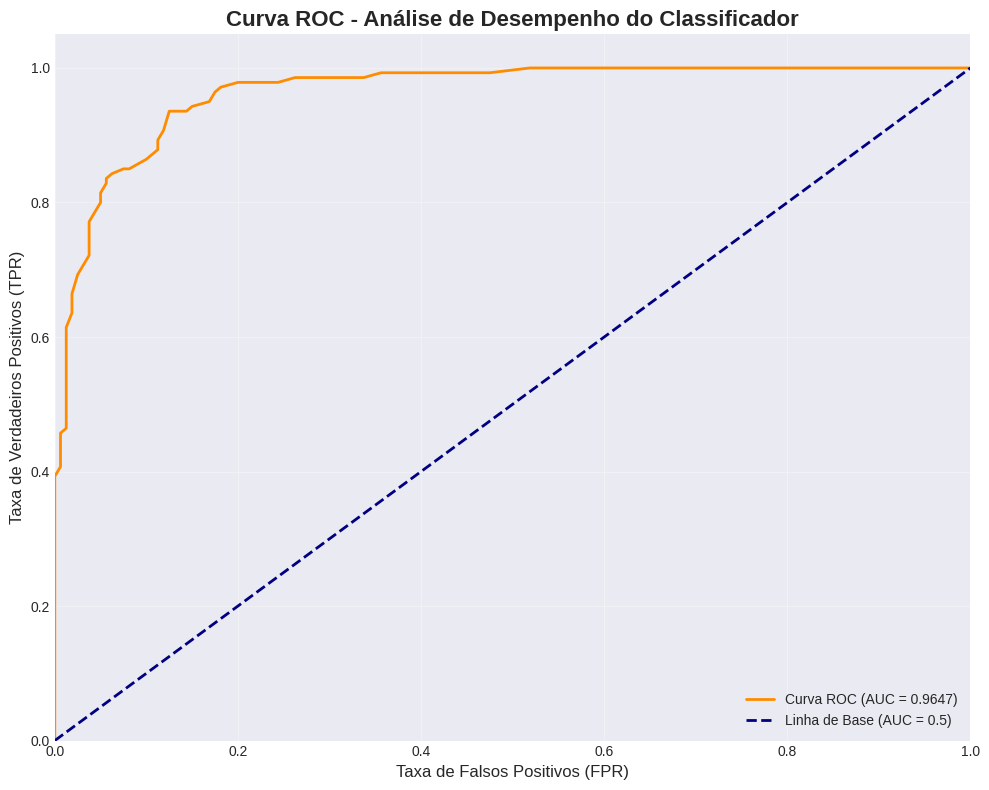

In [7]:
# PASSO 5: GERAR CURVA ROC
print("\n" + "="*50)
print("PASSO 5: Gerando Curva ROC")
print("="*50)

# Calcular pontos da curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"AUC (Area Under Curve): {roc_auc:.4f}")

# Plotar curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Linha de Base (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Análise de Desempenho do Classificador', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# PASSO 6: ANÁLISE DETALHADA DA MATRIZ DE CONFUSÃO
print("\n" + "="*50)
print("PASSO 6: Análise Detalhada da Matriz de Confusão")
print("="*50)

# Criar DataFrame para análise tabular
df_cm = pd.DataFrame(cm,
                     index=['Real: Negativo', 'Real: Positivo'],
                     columns=['Previsto: Negativo', 'Previsto: Positivo'])

print("Tabela da Matriz de Confusão:")
print(df_cm)
print("\n")

# Calcular taxas adicionais
tpr = sensibilidade  # True Positive Rate (Recall)
tnr = especificidade  # True Negative Rate
fpr = FP / (FP + VN) if (FP + VN) > 0 else 0  # False Positive Rate
fnr = FN / (FN + VP) if (FN + VP) > 0 else 0  # False Negative Rate

print("Taxas calculadas:")
print(f"TPR (True Positive Rate/Sensibilidade): {tpr:.4f}")
print(f"TNR (True Negative Rate/Especificidade): {tnr:.4f}")
print(f"FPR (False Positive Rate): {fpr:.4f}")
print(f"FNR (False Negative Rate): {fnr:.4f}")



PASSO 6: Análise Detalhada da Matriz de Confusão
Tabela da Matriz de Confusão:
                Previsto: Negativo  Previsto: Positivo
Real: Negativo                 142                  18
Real: Positivo                  16                 124


Taxas calculadas:
TPR (True Positive Rate/Sensibilidade): 0.8857
TNR (True Negative Rate/Especificidade): 0.8875
FPR (False Positive Rate): 0.1125
FNR (False Negative Rate): 0.1143



PASSO 7: RESUMO FINAL - TODAS AS MÉTRICAS
                   Métrica      Valor
Verdadeiros Positivos (VP) 124.000000
Verdadeiros Negativos (VN) 142.000000
     Falsos Positivos (FP)  18.000000
     Falsos Negativos (FN)  16.000000
                  Acurácia   0.886667
    Sensibilidade (Recall)   0.885714
            Especificidade   0.887500
                  Precisão   0.873239
                  F1-Score   0.879433
                   AUC-ROC   0.964732


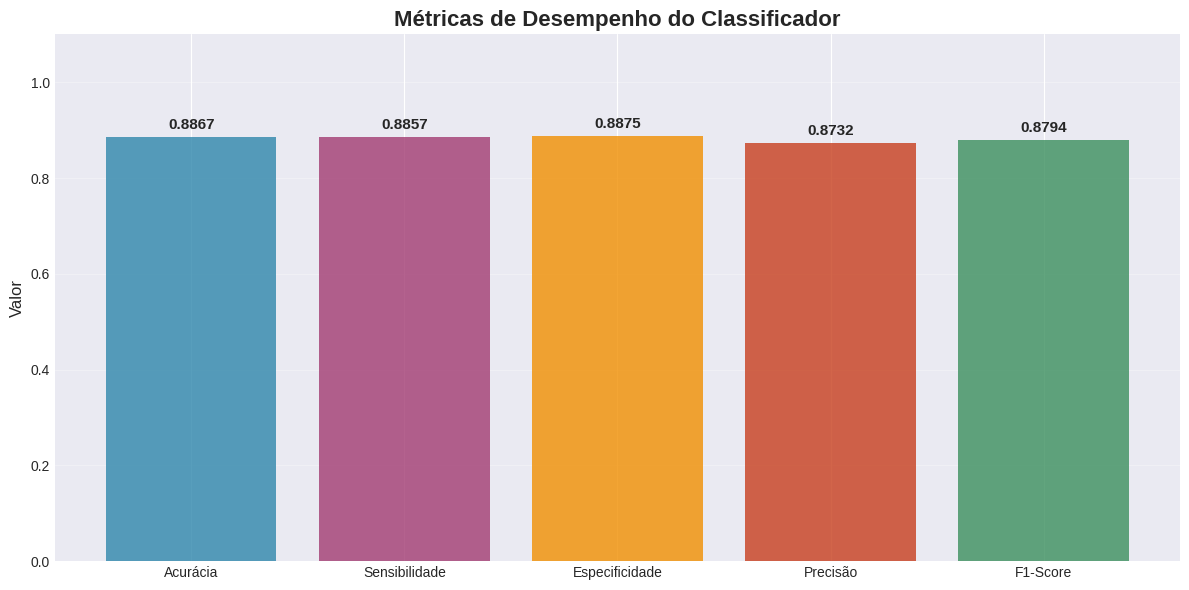


ANÁLISE COMPLETA FINALIZADA COM SUCESSO!


In [9]:
# PASSO 7: RESUMO FINAL
print("\n" + "="*50)
print("PASSO 7: RESUMO FINAL - TODAS AS MÉTRICAS")
print("="*50)

# Criar DataFrame com todas as métricas
metricas = {
    'Métrica': ['Verdadeiros Positivos (VP)',
                'Verdadeiros Negativos (VN)',
                'Falsos Positivos (FP)',
                'Falsos Negativos (FN)',
                'Acurácia',
                'Sensibilidade (Recall)',
                'Especificidade',
                'Precisão',
                'F1-Score',
                'AUC-ROC'],
    'Valor': [VP, VN, FP, FN,
              acuracia_manual,
              sensibilidade,
              especificidade,
              precisao,
              f1_manual,
              roc_auc]
}

df_metricas = pd.DataFrame(metricas)
print(df_metricas.to_string(index=False))

# Visualização adicional: barras das principais métricas
plt.figure(figsize=(12, 6))
metricas_plot = ['Acurácia', 'Sensibilidade', 'Especificidade', 'Precisão', 'F1-Score']
valores_plot = [acuracia_manual, sensibilidade, especificidade, precisao, f1_manual]

cores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B8F5E']
bars = plt.bar(metricas_plot, valores_plot, color=cores, alpha=0.8)
plt.ylim(0, 1.1)
plt.ylabel('Valor', fontsize=12)
plt.title('Métricas de Desempenho do Classificador', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar, val in zip(bars, valores_plot):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ANÁLISE COMPLETA FINALIZADA COM SUCESSO!")
print("="*50)